In [3]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import seaborn as sns

# Đọc dữ liệu từ CSV
df = pd.read_csv('customer_buy_data.csv')
print(df.head())  # Hiển thị 5 dòng đầu tiên để kiểm tra dữ liệu


      Age Income Education  Buy
0   Young    Low      High   No
1   Young    Low      High   No
2   Young   High    Medium  Yes
3  Middle   High       Low  Yes
4  Middle   High       Low   No


In [4]:
# Chuyển giá trị thành số
# Khởi tạo LabelEncoder
le = LabelEncoder()

# Chuyển các cột phân loại thành giá trị số
df['Age'] = le.fit_transform(df['Age'])
df['Income'] = le.fit_transform(df['Income'])
df['Education'] = le.fit_transform(df['Education'])
df['Buy'] = le.fit_transform(df['Buy'])  # Cột mục tiêu nếu cần
print(df.head())  # Hiển thị dữ liệu đã chuyển đổi


   Age  Income  Education  Buy
0    2       1          0    0
1    2       1          0    0
2    2       0          2    1
3    0       0          1    1
4    0       0          1    0


c:\Users\nhiye\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:1473: ConvergenceWarning: Number of distinct clusters (9) found smaller than n_clusters (10). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


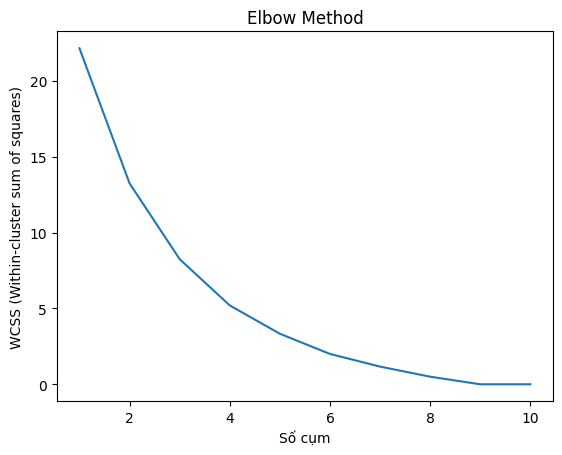

In [5]:
# Sử dụng Elbow Method để tìm số cụm tối ưu
wcss = []  # List để lưu tổng hợp phương sai trong từng cụm

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=0)
    kmeans.fit(df[['Age', 'Income', 'Education']])
    wcss.append(kmeans.inertia_)  # inertia là tổng hợp phương sai trong các cụm

# Vẽ đồ thị Elbow
plt.plot(range(1, 11), wcss)
plt.title('Elbow Method')
plt.xlabel('Số cụm')
plt.ylabel('WCSS (Within-cluster sum of squares)')
plt.show()


    Age  Income  Education  Cluster
0     2       1          0        0
1     2       1          0        0
2     2       0          2        1
3     0       0          1        2
4     0       0          1        2
5     0       1          2        2
6     1       1          1        0
7     1       0          0        0
8     1       0          2        1
9     2       0          2        1
10    0       1          0        2
11    0       1          0        2
12    1       1          2        1


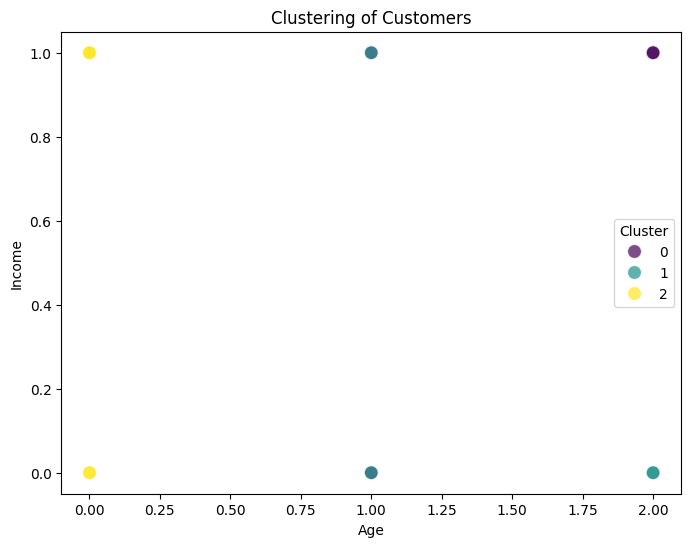

In [6]:
# Áp dụng K-means với số cụm k = 3
kmeans = KMeans(n_clusters=3, init='k-means++', max_iter=300, n_init=10, random_state=0)

# Dự đoán các cụm cho mỗi điểm dữ liệu
df['Cluster'] = kmeans.fit_predict(df[['Age', 'Income', 'Education']])

# Hiển thị kết quả
print(df[['Age', 'Income', 'Education', 'Cluster']])

# Trực quan hóa các cụm bằng biểu đồ
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Age', y='Income', hue='Cluster', palette='viridis', s=100, alpha=0.7)
plt.title('Clustering of Customers')
plt.xlabel('Age')
plt.ylabel('Income')
plt.show()